# Lab 6 — Equalization: ZF, MMSE, Adaptive, Blind, DFE and MLSE

**Companion to Chapter 12** (*Equalization*).
**Time needed:** about 75 minutes. **Difficulty:** core to advanced.

When the channel's delay spread approaches the symbol period, each received sample is a
blend of several symbols: inter-symbol interference (ISI). An equalizer undoes the blend.
The story of this lab is a single trade-off seen from many angles: *inverting the channel
removes ISI but amplifies noise wherever the channel is weak*. Linear MMSE balances the two,
decision feedback sidesteps noise enhancement for post-cursor ISI, and maximum-likelihood
sequence estimation stops fighting the ISI and uses it. Adaptive algorithms (LMS, NLMS, RLS,
CMA) learn all this without being told the channel.

### What you will learn
1. Design zero-forcing and MMSE FIR equalizers and quantify noise enhancement.
2. Choose equalizer length and decision delay.
3. Compare LMS, NLMS and RLS convergence, and blind CMA.
4. Compare linear, decision-feedback and MLSE receivers on a channel with a spectral null.

### Prerequisites
Lab 3 (ISI, Nyquist). Linear algebra: least squares and matrix inverses. Chapter 12.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | An ISI channel; ZF versus MMSE | yes |
| 2 | Noise enhancement, quantified | |
| 3 | Equalizer length and decision delay | |
| 4 | Adaptive equalization: LMS, NLMS, RLS | |
| 5 | Blind equalization: CMA | |
| 6 | Linear vs DFE vs MLSE on a deep null | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import eqadv
from commlib import labkit as lk

rng = lk.setup(seed=6, lab="06")
qpsk = cl.get_constellation("qpsk")
qam16 = cl.get_constellation("16qam")

def channel(a=0.9, theta=0.3):
    """Unit-energy 3-tap channel [1, a e^{j theta}, 0.2]; a -> 1 creates a deep spectral null."""
    return np.array([1, a * np.exp(1j * theta), 0.2]) / np.sqrt(1 + a ** 2 + 0.04)

Lab 06 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 6


## 1. An ISI channel; ZF versus MMSE

Our symbol-spaced channel is $h = [1,\ a\,e^{j\theta},\ 0.2]$ (normalised). As $a \to 1$ its
frequency response develops a deep null. A **zero-forcing** (ZF) FIR equalizer $w$ solves
$h * w \approx \delta[n-\Delta]$ in the least-squares sense: all ISI gone, whatever the noise.
The **MMSE** equalizer minimises $E|z_n - a_{n-\Delta}|^2$ including noise:

$$\mathbf{w}_{\text{MMSE}} = (\mathbf{H}^H\mathbf{H} + N_0\mathbf{I})^{-1}\mathbf{H}^H\mathbf{e}_\Delta .$$

### Interactive: deepen the null and watch ZF blow up

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

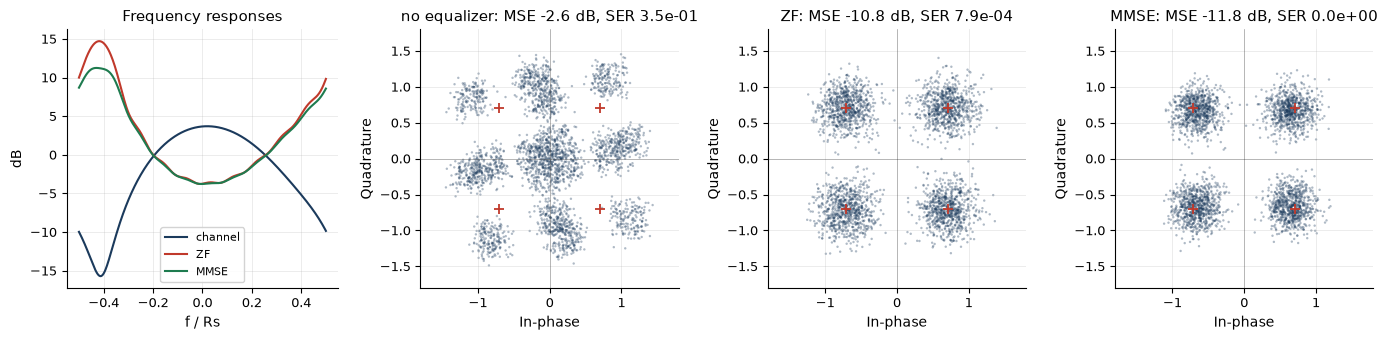

In [3]:
def compare(a=0.9, esn0_db=18.0, L=21, mod="qpsk"):
    c = cl.get_constellation(mod)
    h = channel(a)
    s = c.modulate(cl.random_bits(c.k * 8000, rng))
    y, n0 = cl.awgn_esn0(np.convolve(s, h)[:len(s)], esn0_db, rng=rng, es=1.0)
    wz, dz = cl.zf_fir(h, L)
    wm, dm = cl.mmse_fir(h, L, n0)
    zz, zm = cl.apply_fir(y, wz, dz), cl.apply_fir(y, wm, dm)
    f, ax = lk.fig("row4", 1, 4)
    fr = np.linspace(-0.5, 0.5, 512)
    for w_, lab in [(h, "channel"), (wz, "ZF"), (wm, "MMSE")]:
        ax[0].plot(fr, lk.db(np.abs(np.fft.fftshift(np.fft.fft(w_, 512))) ** 2), label=lab)
    ax[0].set_xlabel("f / Rs"); ax[0].set_ylabel("dB"); ax[0].legend(fontsize=8); ax[0].set_title("Frequency responses")
    sl = slice(200, -200)
    for axi, z, nm in [(ax[1], y, "no equalizer"), (ax[2], zz, "ZF"), (ax[3], zm, "MMSE")]:
        ser = np.mean(c.decide(z[sl]) != s[sl])
        mse = lk.db(np.mean(np.abs(z[sl] - s[sl]) ** 2))
        lk.constellation(axi, z[sl][:3000], c.points, f"{nm}: MSE {mse:.1f} dB, SER {ser:.1e}", lim=1.8)
    lk.show(f)

lk.interact(compare, a=lk.slider(0.9, 0, 1.0, 0.02, "null depth a"),
            esn0_db=lk.slider(18, 5, 35, 1, "Es/N0 (dB)"), L=lk.islider(21, 3, 61, 2, "taps L"),
            mod=lk.choice(["qpsk", "16qam"], desc="modulation"))

**What you should see.** The ZF response is the mirror image of the channel's: a tall peak
where the channel has its null, amplifying the noise there, so the ZF constellation is
noisier than MMSE's even though ZF removes more ISI. MMSE caps its gain at the null.

## 2. Noise enhancement, quantified

For an infinitely long ZF equalizer the output noise variance is
$N_0\int_{-1/2}^{1/2}|H(f)|^{-2}df$, which diverges for a true spectral null. The unbiased
MMSE equalizer's output SNR is $1/\mathrm{MMSE} - 1$. The benchmark is the **matched-filter
bound** (MFB): the SNR you would get from one isolated symbol, $\|h\|^2 E_s/N_0$, which no
receiver can beat.

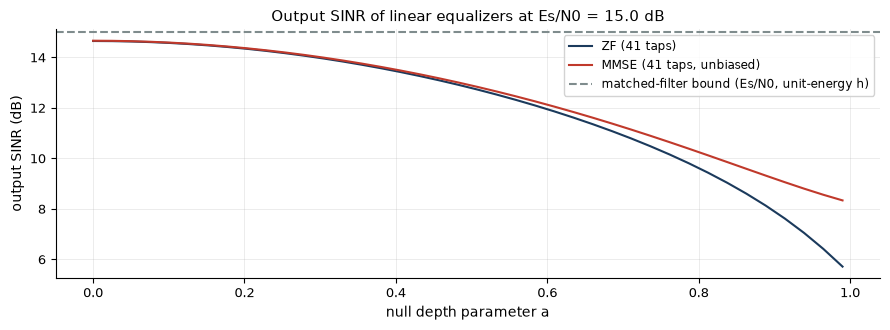

In [6]:
esn0 = 15.0
n0 = 10 ** (-esn0 / 10)
avals = np.linspace(0, 0.99, 40)
snr_zf, snr_mmse = [], []
for a in avals:
    h = channel(a)
    H = cl.conv_matrix(h, 41)
    wz, dz = cl.zf_fir(h, 41)
    wm, dm = cl.mmse_fir(h, 41, n0)
    snr_zf.append(lk.db(1 / (n0 * np.sum(np.abs(wz) ** 2) + np.sum(np.abs(H @ wz - np.eye(H.shape[0])[dz]) ** 2))))
    g = (H @ wm)[dm]
    mse = np.real(1 - g)                                  # MMSE for unit-energy symbols
    snr_mmse.append(lk.db(np.real(g) / mse))              # unbiased output SINR = 1/MMSE - 1
f, ax = lk.fig("wide")
ax.plot(avals, snr_zf, label="ZF (41 taps)")
ax.plot(avals, snr_mmse, label="MMSE (41 taps, unbiased)")
ax.axhline(esn0, color=lk.GRAY, ls="--", label="matched-filter bound (Es/N0, unit-energy h)")
ax.set_xlabel("null depth parameter a"); ax.set_ylabel("output SINR (dB)"); ax.legend()
ax.set_title(f"Output SINR of linear equalizers at Es/N0 = {esn0} dB")
lk.show(f)

**What you should see.** With no ISI ($a = 0$) both are close to the bound. As the null
deepens the ZF output SINR collapses by about 9 dB while MMSE loses about 6 dB, and the
gap between them widens fastest as the null approaches zero.
Neither gets near the MFB for a deep null: that gap is what DFE and MLSE recover in Section 6.

### Try it yourself 2.1
For the two-tap channel $h = [1, 0.5]$ (not normalised), the infinite-length ZF noise gain is
$\int|H(f)|^{-2}df = 1/(1-0.5^2)$. How many dB of noise enhancement is that?

In [8]:
answer_2_1 = None
lk.check("2.1 ZF noise enhancement for h = [1, 0.5] (dB)", answer_2_1, lk.db(1 / (1 - 0.25)), atol=0.05)

[TODO] 2.1 ZF noise enhancement for h = [1, 0.5] (dB): not attempted yet: replace the None with your answer

## 3. Equalizer length and decision delay

An FIR equalizer must approximate an IIR inverse, so it needs enough taps; and because the
ideal inverse of a non-minimum-phase channel is *anti-causal*, the decision delay $\Delta$
(which symbol the output estimates) matters too. Too short or badly delayed, and the MSE floor rises.

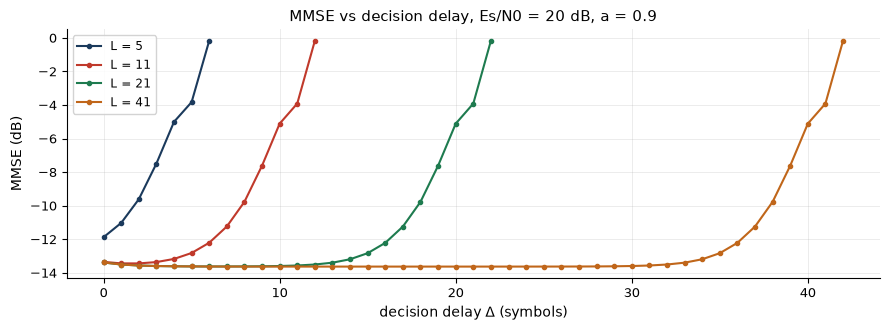

In [10]:
h = channel(0.9)
n0 = 10 ** (-20 / 10)
Ls = [5, 11, 21, 41]
f, ax = lk.fig("wide")
for L in Ls:
    H = cl.conv_matrix(h, L)
    mses = []
    for dly in range(H.shape[0]):
        w, _ = cl.mmse_fir(h, L, n0, delay=dly)
        mses.append(np.real(1 - (H @ w)[dly]))
    ax.plot(np.arange(H.shape[0]), lk.db(mses), "o-", ms=3, label=f"L = {L}")
ax.set_xlabel("decision delay Δ (symbols)"); ax.set_ylabel("MMSE (dB)"); ax.legend()
ax.set_title("MMSE vs decision delay, Es/N0 = 20 dB, a = 0.9")
lk.show(f)

**What you should see.** For each length there is a flat floor over a range of delays and
then a steep wall once Δ approaches the end of the equalizer span, where the filter can no
longer collect the energy of the symbol it is asked to estimate. A 5-tap equalizer never reaches
the floor; beyond about 11–21 taps extra length buys nothing for this channel.

## 4. Adaptive equalization: LMS, NLMS, RLS

In practice the channel is unknown and changing. **LMS** updates
$\mathbf{w} \leftarrow \mathbf{w} + \mu\,\mathbf{u}\,e^*$ using a training sequence, then switches
to decision-directed mode. It is cheap ($O(L)$ per symbol) but its speed depends on the
eigenvalue spread of the input correlation matrix. **NLMS** normalises the step by $\|\mathbf{u}\|^2$.
**RLS** whitens the input with a running inverse correlation matrix, converging in roughly
$2L$ symbols at $O(L^2)$ cost. Misadjustment (excess MSE) of LMS $\approx \mu L P_u/2$.

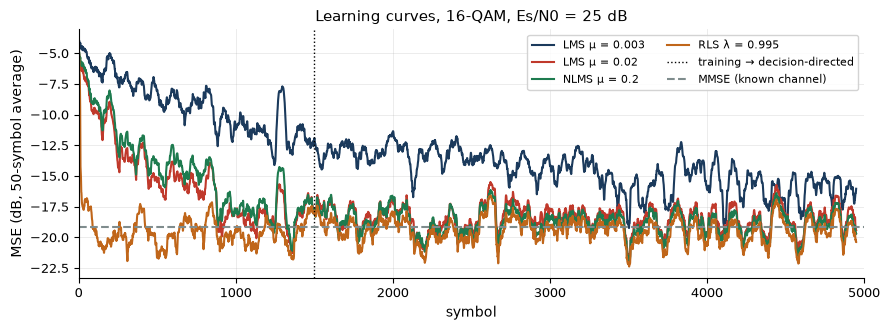

In [13]:
h = channel(0.8)
s = qam16.modulate(cl.random_bits(4 * 5000, rng))
y, n0 = cl.awgn_esn0(np.convolve(s, h)[:len(s)], 25, rng=rng, es=1.0)
wm, dm = cl.mmse_fir(h, 15, n0)
zm = cl.apply_fir(y, wm, dm)
smooth = lambda e: lk.db(np.convolve(e, np.ones(50) / 50, mode="valid"))
f, ax = lk.fig("wide")
for mu in [0.003, 0.02]:
    _, err, _ = cl.lms_equalizer(y, s[:1500], L=15, mu=mu, constellation=qam16)
    ax.plot(smooth(err), label=f"LMS μ = {mu}")
_, err, _ = eqadv.nlms_equalizer(y, s[:1500], L=15, mu=0.2, constellation=qam16)
ax.plot(smooth(err), label="NLMS μ = 0.2")
_, err, _ = eqadv.rls_equalizer(y, s[:1500], L=15, lam=0.995, constellation=qam16)
ax.plot(smooth(err), label="RLS λ = 0.995")
ax.axvline(1500, color="k", ls=":", lw=1, label="training → decision-directed")
ax.axhline(lk.db(np.mean(np.abs(zm[200:-200] - s[200:-200]) ** 2)), color=lk.GRAY, ls="--", label="MMSE (known channel)")
ax.set_xlabel("symbol"); ax.set_ylabel("MSE (dB, 50-symbol average)"); ax.legend(fontsize=8, ncol=2)
ax.set_title("Learning curves, 16-QAM, Es/N0 = 25 dB"); ax.set_xlim(0, 5000)
lk.show(f)

**What you should see.** RLS reaches the MMSE floor within about 50 symbols; a fast LMS
(μ = 0.02) takes several hundred and settles slightly above the floor (misadjustment); a slow
LMS is still converging when training ends, yet decision-directed mode carries on because
its decisions are already mostly right.

## 5. Blind equalization: the constant-modulus algorithm

CMA minimises $E[(|z|^2 - R_2)^2]$ without training *or* carrier lock, because the cost is
phase-invariant. It is the default blind equalizer in GNU Radio's PSK receiver chain and in
`gr02_psk_link.py`, and was the workhorse of cable-TV QAM demodulators. It leaves a phase
ambiguity, resolved afterwards by the carrier loop and the preamble (Lab 4).

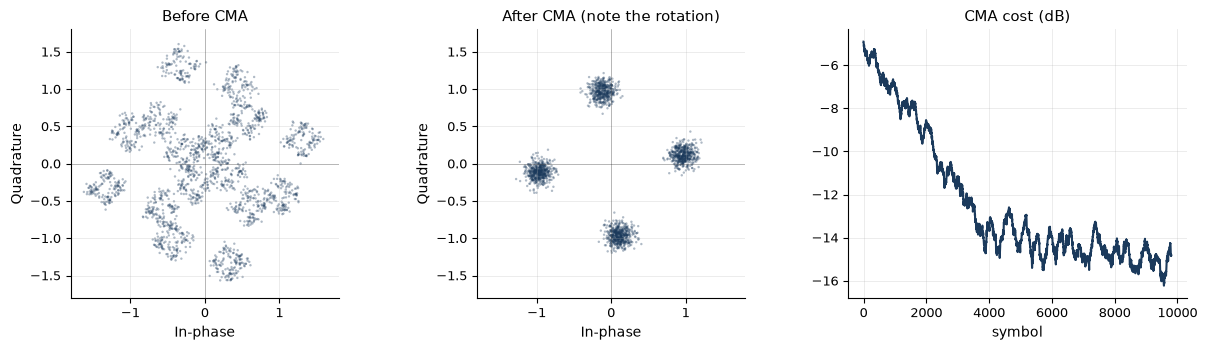

In [16]:
s = qpsk.modulate(cl.random_bits(2 * 10000, rng))
y, _ = cl.awgn_esn0(np.convolve(s, channel(0.7))[:len(s)] * np.exp(1j * 0.9), 22, rng=rng, es=1.0)
z, cost, w = cl.cma_equalizer(y, L=15, mu=3e-3)
f, ax = lk.fig("row3", 1, 3)
lk.constellation(ax[0], y[-2000:], title="Before CMA", lim=1.8)
lk.constellation(ax[1], z[-2000:], title="After CMA (note the rotation)", lim=1.8)
ax[2].plot(lk.db(np.convolve(cost, np.ones(200) / 200, mode="valid"))); ax[2].set_title("CMA cost (dB)")
ax[2].set_xlabel("symbol")
lk.show(f)

**What you should see.** A shapeless cloud becomes four tight clusters on a circle, rotated
by the unknown carrier phase: CMA fixed the ISI without knowing a single symbol.

## 6. Linear vs DFE vs MLSE on a deep null

A **decision-feedback equalizer** cancels post-cursor ISI by subtracting past *decisions*
filtered through a feedback filter, so it does not have to invert the null and does not
amplify noise there. The risk is **error propagation**: one wrong decision corrupts the next
few. **MLSE** (the Viterbi algorithm on the ISI trellis, Forney 1972) finds the most likely
whole sequence; with $M^{L_h-1}$ states it is optimal but exponential in memory. We compare
them on $a = 0.98$, adding a *genie* DFE that feeds back the true symbols (an upper bound on
DFE performance without propagation).

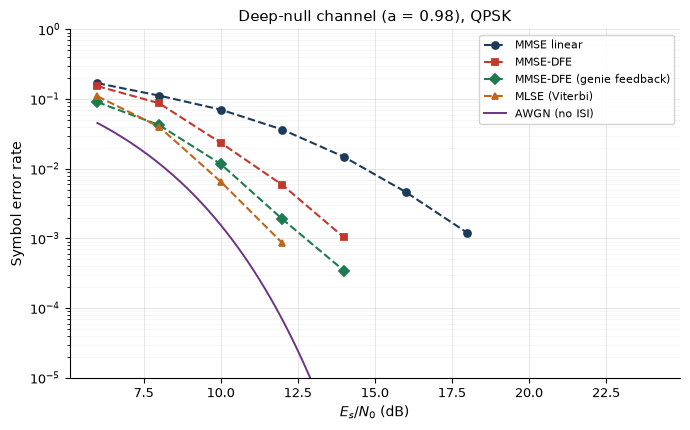

In [19]:
h = channel(0.98)
esv = np.arange(6, 25, 2.0)
res = {k: [] for k in ["MMSE linear", "MMSE-DFE", "MMSE-DFE (genie feedback)", "MLSE (Viterbi)"]}
for e in esv:
    s = qpsk.modulate(cl.random_bits(2 * 6000, rng))
    y, n0 = cl.awgn_esn0(np.convolve(s, h)[:len(s)], e, rng=rng, es=1.0)
    wm, dm = cl.mmse_fir(h, 21, n0)
    zm = cl.apply_fir(y, wm, dm)
    res["MMSE linear"].append(np.mean(qpsk.decide(zm[100:-100]) != s[100:-100]))
    wf, wb, dly, _ = eqadv.mmse_dfe_fir(h, 11, 2, n0)
    _, dec = eqadv.dfe_run(y, wf, wb, dly, qpsk)
    res["MMSE-DFE"].append(np.mean(dec[100:-100] != s[100:len(dec) - 100]))
    _, dec = eqadv.dfe_run(y, wf, wb, dly, qpsk, genie=s)
    res["MMSE-DFE (genie feedback)"].append(np.mean(dec[100:-100] != s[100:len(dec) - 100]))
    a_hat = eqadv.viterbi_mlse(y, h, qpsk.points)
    res["MLSE (Viterbi)"].append(np.mean(a_hat[100:-100] != s[100:-100]))
f, ax = lk.fig("ber")
esf = np.linspace(6, 24, 200)
lk.ber_plot(ax, esv, res, {"AWGN (no ISI)": cl.ser_mqam(esf, 4)}, x_theory=esf, xlabel="$E_s/N_0$ (dB)",
            ylabel="Symbol error rate", ylim=(1e-5, 1))
ax.set_title("Deep-null channel (a = 0.98), QPSK")
lk.show(f)

**What you should see.** The linear MMSE equalizer pays several dB for the null. The DFE
does much better, and its gap to the genie curve is the cost of error propagation (visible
at low SNR). MLSE is best of all, within a couple of dB of the no-ISI AWGN curve: the ISI
energy is not lost, it is *used*.

## Key takeaways
* ZF removes ISI but amplifies noise by $\int|H|^{-2}$; MMSE balances ISI and noise.
* FIR equalizers need enough taps and a sensible decision delay.
* LMS is cheap but slow on ill-conditioned inputs; RLS converges in ~2L symbols at $O(L^2)$ cost;
  CMA needs no training at all.
* DFE avoids noise enhancement for post-cursor ISI but suffers error propagation; MLSE is optimal
  and exponential in channel memory. Wideband systems escape the whole problem with OFDM (Lab 7).

## Going further (hardware: USRP B200 / GNU Radio)
* `gnuradio/gr02_psk_link.py --sim --multipath` uses a CMA equalizer (GNU Radio's
  `Linear Equalizer` with the CMA algorithm). Change its tap count and step size and compare
  with Section 5.
* Put a coaxial cable and splitter in the loopback path (with attenuation!) to create a real
  echo, capture the burst, and run the LMS equalizer of Section 4 on your recording.

## Exercises
1. **(Warm-up)** Show that the infinite-length ZF equalizer's output noise variance is
   $N_0 \int |H(f)|^{-2} df$ and explain why it diverges for a spectral null.
2. **(Core)** Implement a fractionally spaced (T/2) LMS equalizer and show it is insensitive to
   the sampling phase, unlike the T-spaced version.
3. **(Core)** Measure error-propagation burst lengths of the DFE at 10 dB: histogram the length
   of error runs and compare with the genie DFE.
4. **(Stretch)** Build turbo equalization for BPSK: `eqadv.bcjr_isi_bpsk` + the convolutional
   code of Lab 8 with an interleaver, iterating extrinsic information. Plot BER vs iteration.

In [22]:
lk.summary()

[good] Lab 06 finished in 5.2 s. Self-checks: 0 passed, 0 failed, 1 still to do.